In [23]:
import sys
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_core.messages import HumanMessage
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate
sys.path.insert(1, r'C:\Users\Dharmendra Vartika\LLM\env')
from enviorment import load_env
import os 
load_env()
model =ChatOpenAI()

In [6]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict


In [24]:
class BMIstate(TypedDict):
    weight_kg : float
    height_kg: float
    bmi : float 
    category: str
    




In [25]:
def calculate_bmi(state :BMIstate)->BMIstate:
    state['bmi']= round((state['weight_kg'])/(state['height_kg']**2),2)
    return state

In [27]:
def label_bmi(state: BMIstate) -> BMIstate:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [30]:
## define your graph:

graph =StateGraph (BMIstate)

#add nodes to your graph
graph.add_node('Calculate_bmi',calculate_bmi) ## 1st argument is the name of the node and 2nd is the node fuction
graph.add_edge (START,'Calculate_bmi')
graph.add_node('label_bmi',label_bmi)
graph.add_edge ('Calculate_bmi','label_bmi')
graph.add_edge ('label_bmi',END)

In [31]:
## compile it to make sure it is working and no issues 
workflow =graph.compile()
initial_state={"weight_kg":80.0,'height_kg':1.73}

In [32]:
# run the graph
final_state=workflow.invoke(initial_state)
final_state

{'weight_kg': 80.0, 'height_kg': 1.73, 'bmi': 26.73, 'category': 'Overweight'}

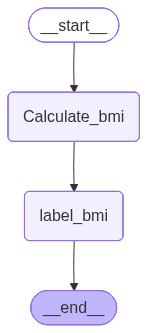

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png()) # this gives us the graph for the display